In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix



iris = load_iris()

X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Number of samples: 150
Number of features: 4


In [3]:
# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Second split: split temp equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 90
Validation set size: 30
Test set size: 30


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [6]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_scaled, y_train)
y_test_pred_3 = knn3.predict(X_test_scaled)

In [7]:
acc_3 = accuracy_score(y_test, y_test_pred_3)
cm_3 = confusion_matrix(y_test, y_test_pred_3)

print("Task 1 - Test Accuracy with K=3:", acc_3)
print("Task 1 - Confusion Matrix:")
print(cm_3)

Task 1 - Test Accuracy with K=3: 0.9333333333333333
Task 1 - Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


In [8]:
# Task 2
k_values = range(1, 16)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_val_pred = knn.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)
    
    print(f"K={k}, Validation Accuracy={acc:.4f}")

K=1, Validation Accuracy=0.9667
K=2, Validation Accuracy=0.9333
K=3, Validation Accuracy=0.9667
K=4, Validation Accuracy=0.9667
K=5, Validation Accuracy=0.9333
K=6, Validation Accuracy=0.9667
K=7, Validation Accuracy=0.9667
K=8, Validation Accuracy=0.9333
K=9, Validation Accuracy=0.9667
K=10, Validation Accuracy=0.9667
K=11, Validation Accuracy=0.9667
K=12, Validation Accuracy=0.9667
K=13, Validation Accuracy=0.9333
K=14, Validation Accuracy=0.9667
K=15, Validation Accuracy=0.9333


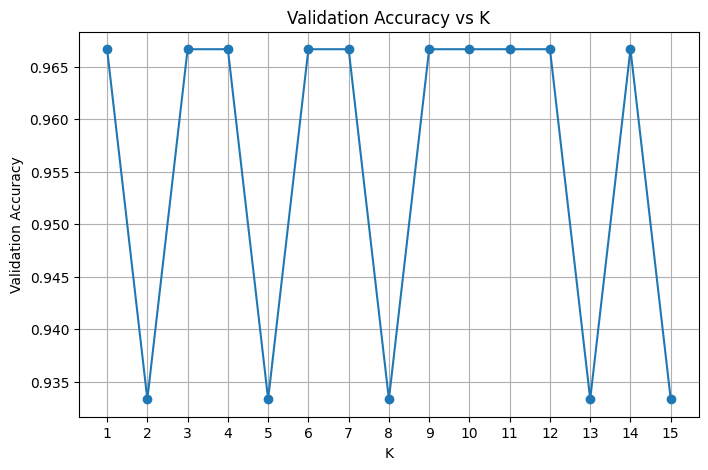

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, val_accuracies, marker='o')
plt.title("Validation Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Validation Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [16]:
best_k = k_values[np.argmax(val_accuracies)]
best_acc = max(val_accuracies)

print("Best K:", best_k)
print("Best Validation Accuracy:", best_acc)

X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))

scaler_final = StandardScaler()
X_train_val_scaled = scaler_final.fit_transform(X_train_val)
X_test_scaled_final = scaler_final.transform(X_test)

Best K: 1
Best Validation Accuracy: 0.9666666666666667


In [19]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_val_scaled, y_train_val)
y_test_pred_best = knn_best.predict(X_test_scaled_final)

acc_best = accuracy_score(y_test, y_test_pred_best)
cm_best = confusion_matrix(y_test, y_test_pred_best)

print("Final Test Accuracy:", acc_best)
print("Confusion Matrix:\n", cm_best)

Final Test Accuracy: 0.9333333333333333
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


In [18]:
print("Task 1 Accuracy (K=3):", acc_3)
print("Task 2 Accuracy (Best K):", acc_best)

Task 1 Accuracy (K=3): 0.9333333333333333
Task 2 Accuracy (Best K): 0.9333333333333333
